# 06 - Feature Importance
## Credit Risk Analysis — Give Me Some Credit

**Objetivo de este notebook:**
- Analizar qué variables son más importantes para cada modelo
- Comparar la importancia de las variables originales vs las nuevas creadas en Feature Engineering
- Extraer conclusiones de negocio sobre los factores de riesgo crediticio

## **Nota de actualización**

Este notebook ha sido actualizado tras eliminar las columnas con multicolinealidad 
en el notebook 04 (`numberoftime30_59dayspastduenotworse`, `numberoftimes90dayslate`, 
`numberoftime60_89dayspastduenotworse`).

Cambios observados respecto a la versión anterior:
- La Regresión Logística ya no muestra coeficientes negativos en las columnas de retrasos
- La multicolinealidad ha sido corregida
- `total_delays` sigue siendo la variable más importante en ambos modelos

In [1]:
# Importamos las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Caragamos dataset limpio
df= pd.read_csv('../data/processed/cs-training-features.csv')

In [2]:
# Ahora tenemos que volver a entrenar los modelos en este nuevo notebook porque no tenemos los modelos en la memoria.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE

# Separamos X e y
X = df.drop('seriousdlqin2yrs', axis=1)
y = df['seriousdlqin2yrs']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Escalado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

# Entrenamos los modelos con los mejores parámetros del tuning
modelo_rf = RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_leaf=1, random_state=42)
modelo_rf.fit(X_train_scaled, y_train_smote)

modelo_lr = LogisticRegression(C=0.01, max_iter=100, random_state=42)
modelo_lr.fit(X_train_scaled, y_train_smote)

print("Modelos entrenados correctamente")

Modelos entrenados correctamente


## Feature Importance — Random Forest

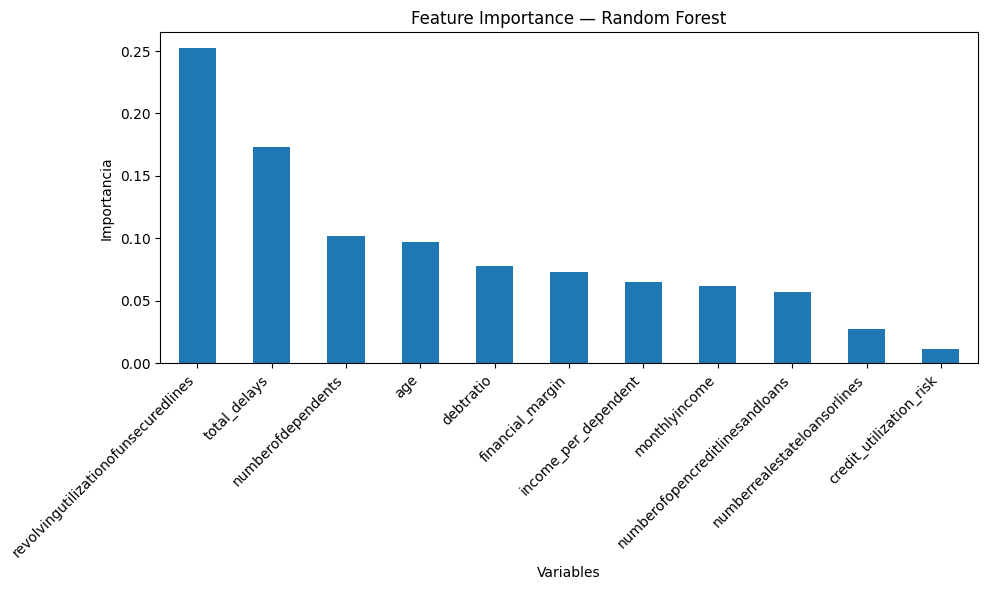

revolvingutilizationofunsecuredlines    0.252326
total_delays                            0.173537
numberofdependents                      0.101724
age                                     0.096882
debtratio                               0.078292
financial_margin                        0.073559
income_per_dependent                    0.065260
monthlyincome                           0.061963
numberofopencreditlinesandloans         0.056888
numberrealestateloansorlines            0.027707
credit_utilization_risk                 0.011862
dtype: float64


In [5]:
# Obtenemos la importancia de cada variable en Random Forest
importancias_rf = pd.Series(modelo_rf.feature_importances_, index=X.columns)
importancias_rf = importancias_rf.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importancias_rf.plot(kind='bar')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Variables')
plt.ylabel('Importancia')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(importancias_rf)

## Observaciones:
- Las variables más destacadas son 'revolvingutilizationofunsecuredlines' y 'total_delays'
- De las variables creadas, las que aportan valor al dataset son 'total_delays', 'financial_margin' e 'income_per_dependent'
- 'credit_utilization_risk' no aporta apenas valor, y creo que eso se debe a que creamos esta variable para que fuera binaria, y eso hizo que simplificara mucha información.

## Feature Importance — Regresión Logística

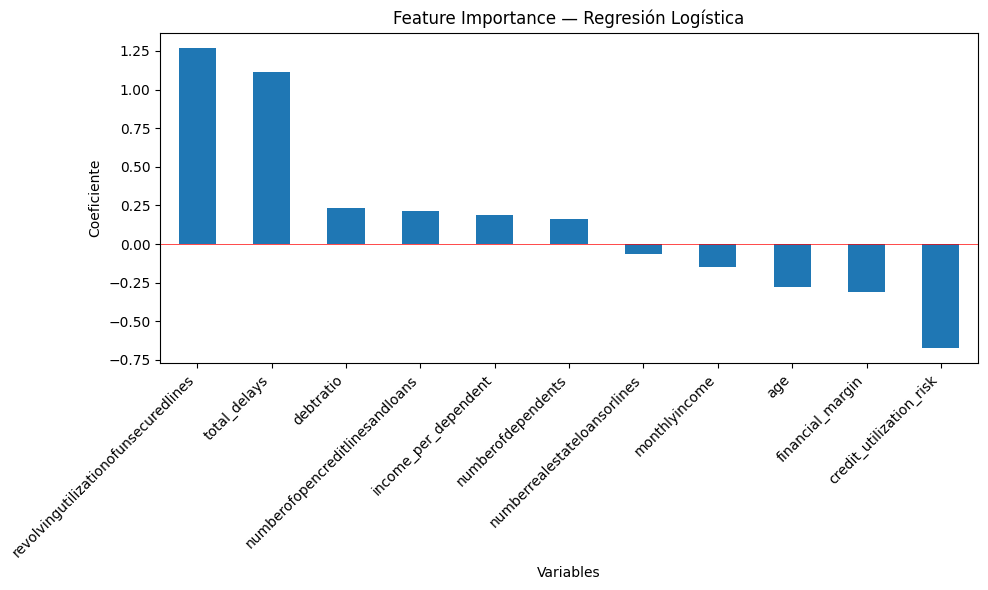

revolvingutilizationofunsecuredlines    1.269429
total_delays                            1.115822
debtratio                               0.234087
numberofopencreditlinesandloans         0.216310
income_per_dependent                    0.184939
numberofdependents                      0.160314
numberrealestateloansorlines           -0.062949
monthlyincome                          -0.146681
age                                    -0.277087
financial_margin                       -0.308277
credit_utilization_risk                -0.675065
dtype: float64


In [4]:
# En Regresión Logística usamos los coeficientes en lugar de feature_importances_
importancias_lr = pd.Series(modelo_lr.coef_[0], index=X.columns)
importancias_lr = importancias_lr.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importancias_lr.plot(kind='bar')
plt.title('Feature Importance — Regresión Logística')
plt.xlabel('Variables')
plt.ylabel('Coeficiente')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=0, color='r', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

print(importancias_lr)

## Observaciones:
- Las variables que aumentan el riesgo de impago son 'total_delays' y 'revolvingutilizationofunsecuredlines'
- Las columnas de retrasos tenían coeficiente negativo porque 'total_delays' recogía la información de esas variables, he hicíera que hubiera multicolinealidad (las variables están correlacionadas y se compensa entre sí). Ahora, ya actualizado las variables con coeficiente negativo son 'credit_utilization_risk','financial_margin','age','montlyincome'

## Conclusiones generales — Feature Importance

- En ambos modelos, `revolvingutilizationofunsecuredlines` y `total_delays` son las variables más importantes para predecir el riesgo de impago.
- Las nuevas variables creadas en Feature Engineering aportan valor real al modelo — especialmente `total_delays` que es la más importante en Regresión Logística.
- `credit_utilization_risk` es la variable menos útil en ambos modelos — por ser binaria pierde demasiada información.
- Desde el punto de vista del negocio: el historial de retrasos y el nivel de utilización del crédito son los factores más determinantes para predecir si un cliente tendrá problemas de pago.
- La multicolinealidad mecionada antes puede suponer un problema para el modelo de Regresión Logística, porque el modelo no sabrña bien a que variable darle más peso, y eso hará que los coeficientes se vuelvan inestables (signos negativos), así que para evitar esos, eliminaremos las columnas individuales de retrasos, y dejaremos solo 'total_delays' como indicador global. Esta modificación se hace en el notebook 04_feature_engineering en "## Eliminación de columnas con multicolinealidad".
- Para evitar la multicolinealidad, lo que haremos será en el notebook 04, eliminar las columnas de 'numberoftime30_59dayspastduenotworse','numberoftimes90dayslate','numberoftime60_89dayspastduenotworse', después se volverá a ejecutar el notebook 05 para que vuelva a entrenar los modelos con el nuevo y ñultimo dataset actualizado, y lo mismo para el el notebook 6, para dejarlo al final todo actualizado.